In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('/home/samri/climate-challenge-week0/data/sudan.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
1,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
2,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
3,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86
4,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11


In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4102,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52
4103,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44
4104,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12
4105,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18
4106,2026,90,33.79,42.64,25.73,16.91,0.0,13.89,3.52,5.00,95.89,4.47


In [4]:
df.sample(5)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
1195,2018,101,28.44,37.45,19.68,17.77,0.00,12.59,3.90,5.71,96.16,2.93
3834,2025,183,32.12,38.44,27.45,10.99,1.86,48.73,5.50,7.07,96.29,14.58
1927,2020,103,27.79,34.19,21.24,12.95,0.00,14.04,4.98,7.68,96.49,3.20
43,2015,45,22.06,32.87,12.37,20.50,0.00,15.43,3.26,4.87,96.60,2.46
3652,2025,1,19.88,28.81,12.16,16.65,0.00,29.58,4.97,6.92,96.96,4.34


In [5]:
display(df.describe())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000
mean,2020.132700,180.164841,28.759878,36.774212,21.509817,15.264395,0.644032,31.359067,3.484259,5.157387,96.346226,7.864991
std,3.248315,106.270943,4.681542,4.400559,5.091072,3.298687,3.058028,17.854021,1.040793,1.280393,0.266942,4.881449
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000
25%,2017.000000,86.000000,25.560000,33.730000,17.500000,13.280000,0.000000,17.405000,2.730000,4.265000,96.160000,3.730000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.890000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.560000,4.220000,6.020000,96.510000,12.500000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000


Data Loading & Date Parsing

In [7]:
df["Country"] = "Sudan"
# Create datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
1,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
2,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
3,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
4,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11,Sudan,2015-01-06,1


Handle Missing Values (-999)

In [8]:
df.replace(-999, np.nan, inplace=True)

Duplicate Check

In [9]:
duplicates = df.duplicated().sum()
duplicates

0

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,28.759878,36.774212,21.509817,15.264395,0.644032,31.359067,3.484259,5.157387,96.346226,7.864991,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.500000,13.280000,0.000000,17.405000,2.730000,4.265000,96.160000,3.730000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.890000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.560000,4.220000,6.020000,96.510000,12.500000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,4.681542,4.400559,5.091072,3.298687,3.058028,17.854021,1.040793,1.280393,0.266942,4.881449,NaN,3.476439


Missing Value Report

In [11]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Outlier Detection (Z-score)

In [12]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

outlier_rows = np.where(outliers)
len(set(outlier_rows[0]))

84

Handle Outliers

In [13]:
outlier_df = df[(z_scores > 3).any(axis=1)]
outlier_df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84,84.000000
mean,2020.547619,199.773810,27.115238,32.264405,23.174405,9.090000,16.088690,63.987143,3.791429,5.542024,96.374881,15.048810,2021-02-03 03:25:42.857142784,7.071429
min,2015.000000,9.000000,13.180000,21.040000,5.930000,3.420000,0.000000,13.610000,0.610000,1.030000,96.060000,2.290000,2015-01-09 00:00:00,1.000000
25%,2019.000000,200.250000,26.667500,30.345000,23.317500,7.225000,10.877500,61.152500,2.927500,4.480000,96.225000,15.587500,2019-06-29 06:00:00,7.000000
50%,2021.000000,218.000000,27.795000,32.715000,24.230000,8.580000,13.110000,69.040000,3.705000,5.380000,96.310000,16.565000,2021-07-05 12:00:00,8.000000
75%,2023.000000,236.000000,28.867500,34.562500,24.842500,10.415000,19.460000,75.732500,4.570000,6.852500,96.422500,17.592500,2023-08-07 00:00:00,8.000000
max,2025.000000,314.000000,32.640000,41.230000,27.810000,17.390000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2025-09-05 00:00:00,11.000000
std,2.855579,65.770018,3.869666,3.945231,4.421840,3.053977,12.478708,17.659764,1.259524,1.560244,0.273017,4.515474,NaN,2.194109


Interpretation of Your Outlier Summary


1. Temperature (T2M, T2M_MAX, T2M_MIN)
Key values:
Mean T2M = 27.12°C
Max T2M_MAX = 41.23°C
Min T2M_MIN = 5.93°C
Std ≈ 3.87°C (high variability)
Insight:
This is the hottest dataset so far
Extreme heat events occur (above 40°C)
Also occasional very cold outliers (~5°C)

Interpretation:

The region experiences very high temperatures with significant variability, including extreme heatwaves exceeding 40°C.

2. Rainfall (PRECTOTCORR)
Key values:
Mean = 16.09
Max = 66.49
Min = 0
Std ≈ 12.48
Insight:
Rainfall is moderately variable
Dry days exist (0 rainfall)
Heavy rainfall events occur but are less extreme than previous dataset

Interpretation:

The region shows seasonal rainfall patterns with occasional heavy precipitation events.

3. Humidity (RH2M)
Key values:
Mean = 63.99% (lowest among all datasets)
Min = 13.61% (very dry conditions)
Max = 87.16%
Insight:
Very dry conditions are present
Strong variability in humidity
Overall drier climate compared to previous datasets

Interpretation:

The region is relatively dry with significant fluctuations in atmospheric moisture.

4. Wind Speed (WS2M, WS2M_MAX)
Mean wind = 3.79 (highest among all datasets)
Max wind = 9.05
Insight:
Strong wind conditions compared to other regions
High variability in wind speeds

Interpretation:

This region experiences consistently stronger wind activity, indicating more dynamic atmospheric conditions.

5. Pressure (PS)
Mean = 96.37 (lowest among datasets)
Max = 97.31
Insight:
Lower atmospheric pressure compared to others
Slight variability but still relatively stable

Interpretation:

Lower pressure values suggest different elevation or climatic zone compared to other regions.

6. Temporal Distribution
Years: 2015 → 2025
Months mostly around July–August (median ~7–8)

Interpretation:

Data is concentrated in mid-year months, so seasonal conclusions should be interpreted carefully.

7. Overall Climate Profile Insight

Compared to previous datasets:

Feature	Observation
Temperature	Hottest and most extreme
Humidity	Lowest (driest region)
Wind	Strongest wind activity
Rainfall	Moderate but variable
Pressure	Lowest overall

Final Interpretation 

This dataset represents a hot, dry, and highly dynamic climate region characterized by extreme temperature variability, including heatwaves exceeding 40°C. Humidity levels are relatively low compared to other regions, indicating arid conditions. Wind speeds are consistently higher, suggesting strong atmospheric movement. Overall, this region exhibits a dry and extreme climate system distinct from the other datasets analyzed.

Handle Missing Values

In [16]:
# Drop rows with >30% missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_38712/1879083505.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


Export Clean Data 

In [17]:
df.to_csv("/home/samri/climate-challenge-week0/data/sudan_clean.csv", index=False)

Time Series Analysis

Temperature Trend

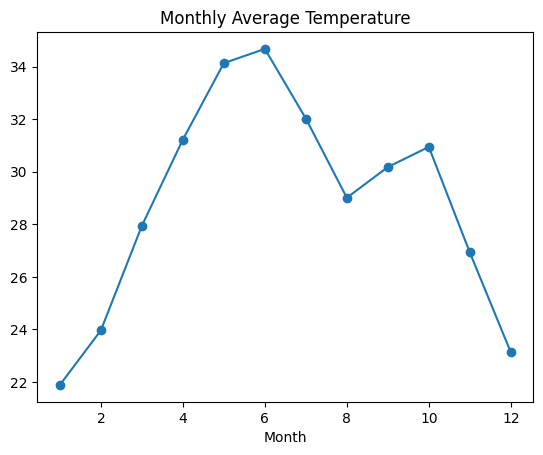

In [18]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", marker="o")
plt.title("Monthly Average Temperature")
plt.show()

In [19]:
monthly_temp.idxmax(), monthly_temp.max()
monthly_temp.idxmin(), monthly_temp.min()

(1, 21.886846361185984)

Rainfall Trend

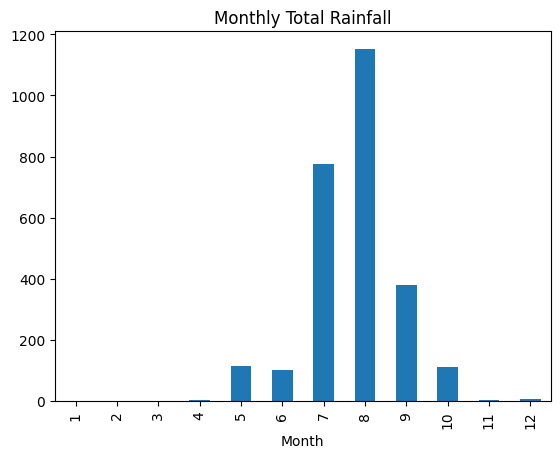

In [20]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

Correlation Analysis

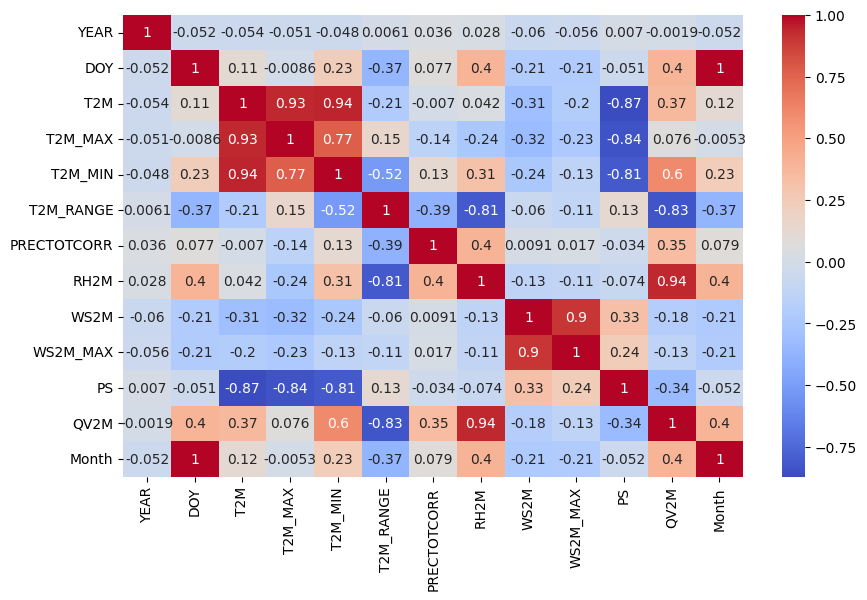

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Scatter plots

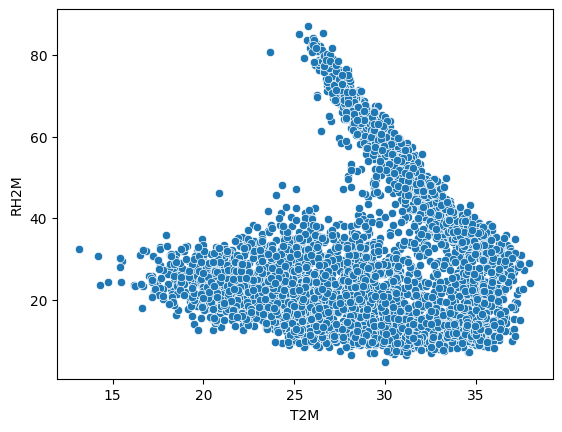

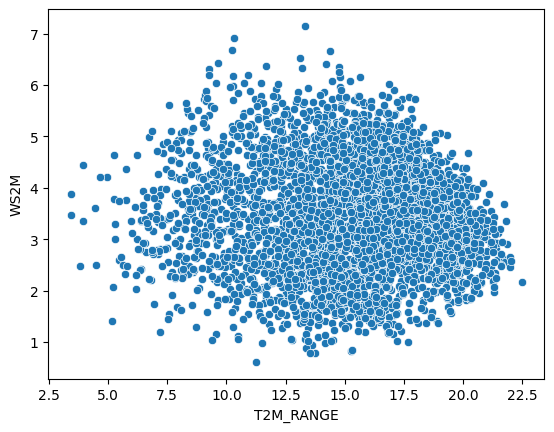

In [22]:
sns.scatterplot(x=df["T2M"], y=df["RH2M"])
plt.show()

df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.show()

Distribution Analysis

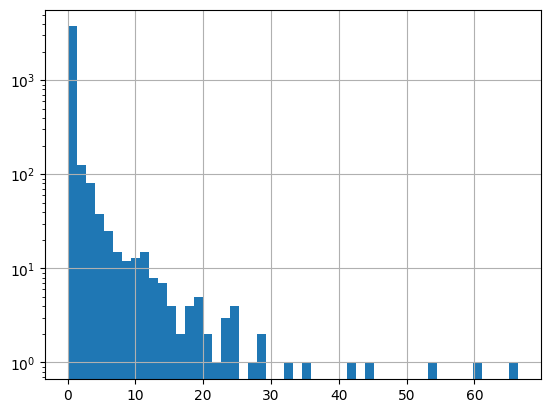

In [23]:
df["PRECTOTCORR"].hist(bins=50)
plt.yscale("log")  # if skewed
plt.show()

Bubble Chart

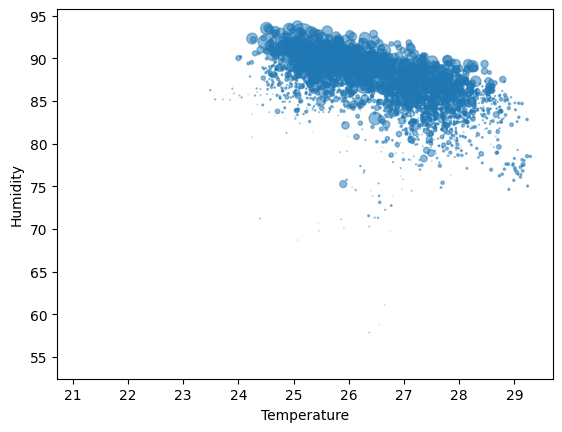

In [23]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*2,
    alpha=0.5
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()